# Assignment 01: Exploratory Data Analysis of the New York City Airbnb Listings Dataset

This assignment presents a comprehensive Exploratory Data Analysis (EDA) of the **New York City Airbnb Open Data (2019)**.

The goal of this analysis is to understand the factors influencing listing prices, explore patterns in room types and neighbourhood groups, and identify opportunities for hosts. The analysis involves data cleaning, feature engineering, univariate and multivariate visualizations, and statistical exploration using Python libraries such as Pandas, Matplotlib, and Seaborn.



## Loading the Dataset

For this assignment, we will use the real-world, publicly available **New York City Airbnb Open Data (2019)**, which contains information regarding approximately 4,900 Airbnb listings across New York City’s five boroughs, including details about hosts, room types, pricing, location, yearly availability, minimum nights and review activity.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("new_york_airbnb_listings.csv")
df.head(10)

Saving new_york_airbnb_listings.csv to new_york_airbnb_listings (1).csv


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,32785169,2 Bedroom Refuge with Private Bath & Living Room,20433973,Julia,Bronx,City Island,40.83988,-73.78287,Private room,95,1,6,2019-06-17,1.65,2,359
1,34399984,Two private rooms,259690766,Souadou,Bronx,Belmont,40.85648,-73.88501,Private room,95,2,4,2019-07-01,2.35,1,325
2,36379669,Shared living space in the Bronx!,44378432,Bryan,Bronx,Pelham Bay,40.84735,-73.83095,Shared room,50,1,0,NaN,NaN,1,88
3,35249458,Light-filled comfortable entire apartment,264809787,Kurt,Bronx,Concourse Village,40.82778,-73.91516,Entire home/apt,75,3,2,2019-06-21,2.00,1,253
4,30253236,SedaOn2 Dance Studio,140862407,Angelie,Bronx,Westchester Square,40.84378,-73.84469,Entire home/apt,670,1,2,2019-03-31,0.34,1,178
5,16506121,Beautifully private furnished room,108464471,Jeremiah,Bronx,Longwood,40.81790,-73.91456,Private room,100,6,0,NaN,NaN,1,365
6,19974905,Esteem's Place,141615596,Esteem,Bronx,Parkchester,40.83805,-73.85867,Shared room,26,1,18,2019-04-23,0.78,2,342
7,12345615,Natural light comfortable room!,52196858,Danny,Bronx,Parkchester,40.83648,-73.85812,Private room,59,1,120,2019-07-02,3.11,2,336
8,16476956,Newly renovated & Fully Furnished Super clean,51065605,Charles,Bronx,Port Morris,40.80743,-73.92971,Entire home/apt,115,5,7,2019-07-01,0.23,1,7
9,33363084,E community that is commercially (Website hidd...,242175033,Alex,Bronx,Allerton,40.86003,-73.86584,Entire home/apt,60,1,28,2019-07-02,8.32,1,74


## Step 1: Inspecting the Data

Before choosing an appropriate chart for visualization, first we will check the shape of the dataset, identify data types for all columns, display descriptive statistical numeric data, identify null values and duplicate records and create two separate lists of numeric and categorical columns.

In [4]:
df.shape

(4889, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4889 entries, 0 to 4888
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              4889 non-null   int64  
 1   name                            4886 non-null   object 
 2   host_id                         4889 non-null   int64  
 3   host_name                       4889 non-null   object 
 4   neighbourhood_group             4889 non-null   object 
 5   neighbourhood                   4889 non-null   object 
 6   latitude                        4889 non-null   float64
 7   longitude                       4889 non-null   float64
 8   room_type                       4889 non-null   object 
 9   price                           4889 non-null   int64  
 10  minimum_nights                  4889 non-null   int64  
 11  number_of_reviews               4889 non-null   int64  
 12  last_review                     38

In [6]:
df.isnull().sum()

,0
id,0
name,3
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889000e+03,4.889000e+03,4889.000000,4889.000000,4889.00000,4889.000000,4889.000000,3879.000000,4889.000000,4889.000000
mean,1.902666e+07,6.697190e+07,40.728549,-73.952288,155.46533,6.825731,23.643485,1.399588,6.830027,115.726529
std,1.091048e+07,7.795207e+07,0.054869,0.045684,286.86715,17.227167,43.762044,1.889328,31.722288,132.295573
min,5.803000e+03,2.787000e+03,40.522930,-74.212380,0.00000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.497513e+06,8.138665e+06,40.689760,-73.982950,70.00000,1.000000,1.000000,0.200000,1.000000,0.000000
50%,1.972056e+07,3.028359e+07,40.723060,-73.955720,106.00000,3.000000,5.000000,0.750000,1.000000,50.000000
75%,2.913442e+07,1.072729e+08,40.763060,-73.936710,179.00000,5.000000,24.000000,2.025000,2.000000,235.000000
max,3.648466e+07,2.743115e+08,40.903560,-73.726000,10000.00000,365.000000,447.000000,58.500000,327.000000,365.000000


In [9]:
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

Numeric columns: ['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
Categorical columns: ['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'room_type', 'last_review']


### Initial Observations:

1. The columns `name`, `last_review` and `reviews_per_month` have a significant number of missing values, which indicates that many listings either have no reviews or the review data was not recorded. Some listings have missing names also.

2. From the `describe()` output, the `price` column shows a maximum value of **10,000**, while 75% of the listings are priced at or below **179**. Similarly, `minimum_nights` has a maximum value of **365**, which is unrealistic for most short-term rentals. Such extreme values are major indicators showing presence of outliers that need to be handled effectively.

3. The dataset contains a mix of numerical and categorical columns. Some columns such as `id` and `host_id` are stored as integers, but are identifiers. Additionally, columns such as `name` and `neighbourhood` have high cardinality (multiple unique values), which may require careful handling during EDA.



## Step 2: Data Cleaning and Pre-Processing
In this step, missing values in the dataset are handled by dropping rows with missing names and filling missing review-related columns with appropriate values. Outliers in the `price` and `minimum_nights` columns were identified and removed using the Interquartile Range (IQR) method along with practical thresholds. Additionally, a new column `price_category` was engineered to categorize listings into **Budget**, **Mid-Range**, and **Luxury segments** for better analysis.

In [10]:
df = df.dropna(subset=['name'])

df['reviews_per_month'] = df['reviews_per_month'].fillna(0.00)

df['last_review'] = df['last_review'].fillna('No review')

print("Missing value count per column: ", df.isnull().sum())

Missing value count per column:  id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


**Handling Missing Values:**

Missing values were detected in `name`, `last_review`, and `reviews_per_month` columns.

- Listings with missing `name` were dropped.

- Missing `reviews_per_month` were filled with **0.00**.
- Missing `last_review` were filled with **No Review**.

**Justification:**

These three strategies were implemented because they are logical and preserve the maximum amount of data while making sense for the nature of the missing values.


In [14]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound_price = max(0, Q1 - 1.5 * IQR)
upper_bound_price = Q3 + 1.5 * IQR

print(f"Lower Bound Price: {lower_bound_price}")
print(f"Upper Bound Price: {upper_bound_price}")

df = df[(df['price'] >= lower_bound_price) & (df['price'] <= upper_bound_price)]

df = df[(df['minimum_nights'] >= 1) & (df['minimum_nights'] <= 30)]

print("Shape of the dataset after removing outliers: ", df.shape)

Lower Bound Price: 0
Upper Bound Price: 301.0
Shape of the dataset after removing outliers:  (4503, 17)


**Handling Outliers:**

The IQR (interquartile range) method was used for the `price` column. For `minimum_nights`, a reasonable maximum value of **30 nights** was used.

**Justification**:

While the IQR method enforced stricter limits for `minimum_nights`, a cutoff of 30 was chosen since most legitimate listings require up to 30 nights minimum stay. Hence, this removed extreme, unrealistic outliers while keeping realistic data.


In [12]:
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

**Fixing Data Types:**

The `last_review` column was converted from `object` to `datetime` format directly using Pandas.

**Justification**:

This allows quicker and better date-based analysis (e.g., date/time recorded since last review).


In [13]:
def categorize_price(price):
    if price < 80:
        return 'Budget'
    elif 80 <= price < 200:
        return 'Mid-Range'
    else:
        return 'Luxury'

df['price_category'] = df['price'].apply(categorize_price)

print(df[['price', 'price_category']].head(10))

    price price_category
0      95      Mid-Range
1      95      Mid-Range
2      50         Budget
3      75         Budget
5     100      Mid-Range
6      26         Budget
7      59         Budget
8     115      Mid-Range
9      60         Budget
10     60         Budget


**Feature Engineering – New Column Created:**

A new column `price_category` was created by categorizing the `price` column into three distinct groups:

- **Budget**: Listings priced below $80

- **Mid-Range**: Listings priced in the range $(80, 200)

- **Luxury**: Listings priced $200 or above

**Logic Behind the Column:**

This column was engineered to simplify analysis and better understand how different price segments behave in the market. Instead of treating price as a continuous variable only, grouping it into categories allows for clearer comparison of listing characteristics (e.g. room type, location, and review activity) across distinct price levels. The thresholds were applied after analyzing the price distribution, where most listings fall under $200.


## Step 3: Performing Univariate Analysis

In this step, we performed univariate analysis to analyze the distribution of individual variables in the dataset. We explored both numerical and categorical columns by implementing appropriate visualization techniques such as histograms and count plots.

### Visualization 1: Price Distribution
A histogram is created below to show the distribution of `price` for each listing.

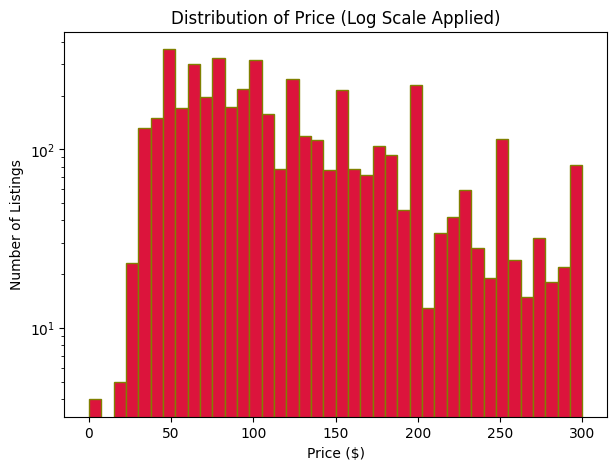

In [20]:
plt.figure(figsize=(7, 5))
plt.hist(df['price'], bins=40, color='crimson', edgecolor='olive', log=True)
plt.title('Distribution of Price (Log Scale Applied)')
plt.xlabel('Price ($)')
plt.ylabel('Number of Listings')

plt.show()



**Interpretation:**

- The price distribution is heavily right-skewed.
- Most listings are concentrated in the lower price range $(50-150).

- Using a log scale on the y-axis helps us see the pattern more clearly in the less frequent higher-priced listings.

### Visualization 2: Distribution of Minimum Nights
A histogram is generated below to represent the distribution of `minimum_nights` required for each listing.

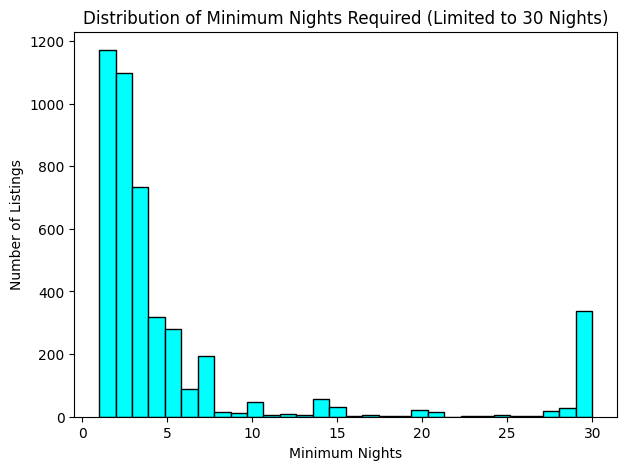

In [22]:
plt.figure(figsize=(7, 5))
plt.hist(df[df['minimum_nights'] <= 30]['minimum_nights'], bins=30, color='cyan', edgecolor='black')
plt.title('Distribution of Minimum Nights Required (Limited to 30 Nights)')
plt.xlabel('Minimum Nights')
plt.ylabel('Number of Listings')

plt.show()

**Interpretation:**

- Most listings require a very short minimum stay of 1 to 5 nights.
- The distribution is heavily right-skewed, with only a small number of listings requiring more than 10 nights.
- The spike at 30 nights suggests that some hosts intentionally set a monthly minimum stay requirement.

- Because the `minimum_nights` column is right-skewed, we limited the range to 30 nights so that the main pattern of distribution is clearly visible and simple to interpret.


### Visualization 3: Counting Listings Per Room Type
The bar chart below is generated to represent the number of listings for each room type.

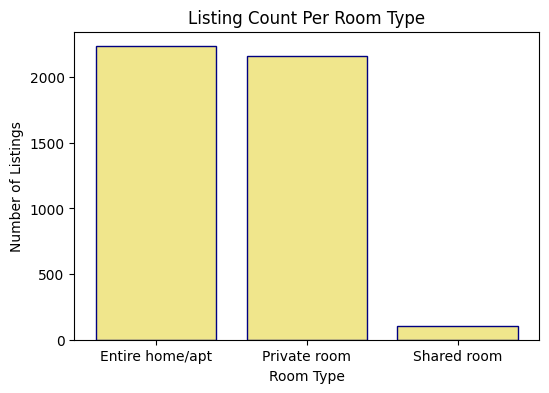

In [24]:
number_of_rooms = df['room_type'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(number_of_rooms.index, number_of_rooms.values, color='khaki', edgecolor='navy')
plt.title('Listing Count Per Room Type')
plt.xlabel('Room Type')
plt.ylabel('Number of Listings')

plt.show()

**Interpretation:**

- Entire home/apartment and Private room are viewed as the two dominant room types throughout the dataset, with almost equal numbers of listings.
- Shared rooms make up only a very minor portion.

- This indicates that majority hosts prefer to offer private or entire room spaces rather than shared accommodations.


### Visualization 4: Counting Listings Per Neighbourhood Group
A horizontal countplot created below displays the number of listings in each neighbourhood group (borough).

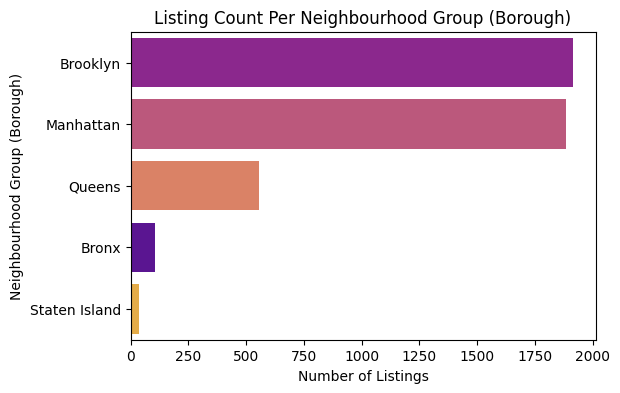

In [32]:
plt.figure(figsize=(6, 4))
sns.countplot(y='neighbourhood_group', data=df, hue='neighbourhood_group', order=df['neighbourhood_group'].value_counts().index, palette='plasma', legend=False)
plt.title('Listing Count Per Neighbourhood Group (Borough)')
plt.xlabel('Number of Listings')
plt.ylabel('Neighbourhood Group (Borough)')

plt.show()

**Interpretation:**

- Brooklyn has the highest number of listings, followed closely by Manhattan.
- Queens has a moderate number of listings.
- Bronx and Staten Island have significantly fewer number of listings.

- This infers that most Airbnb activity in the dataset is concentrated in Brooklyn and Manhattan, compared to Bronx and Staten Island.

## Step 4: Performing Bivariate and Multivariate Analysis



### Visualization 1: Listing Price Distribution Across Different Neighbourhood Groups (Boroughs)

The box plot created below shows how listing prices vary across different neighbourhood groups.





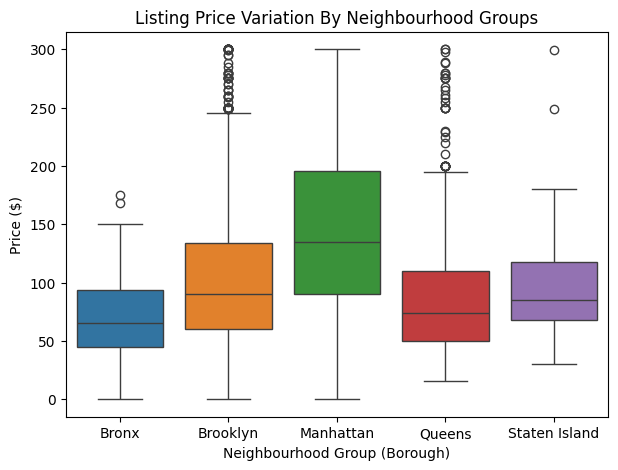

In [39]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='neighbourhood_group', y='price', hue='neighbourhood_group', data=df, legend=False)
plt.title('Listing Price Variation By Neighbourhood Groups')
plt.xlabel('Neighbourhood Group (Borough)')
plt.ylabel('Price ($)')

plt.show()

**Interpretation:**

- Manhattan has the highest median price and the widest price range among all neighbourhood groups.

- Brooklyn has moderately high prices.
- Queens, Staten Island, and Bronx have comparatively lower median prices.
- This clearly shows that the location of each listing has a strong influence on its price, with Manhattan being observed as the most expensive neighbourhood group.

### Visualization 2: Listing Price Distribution Across Different Room Types

The scatter plot generated below represents how listing prices vary across distinct room types.

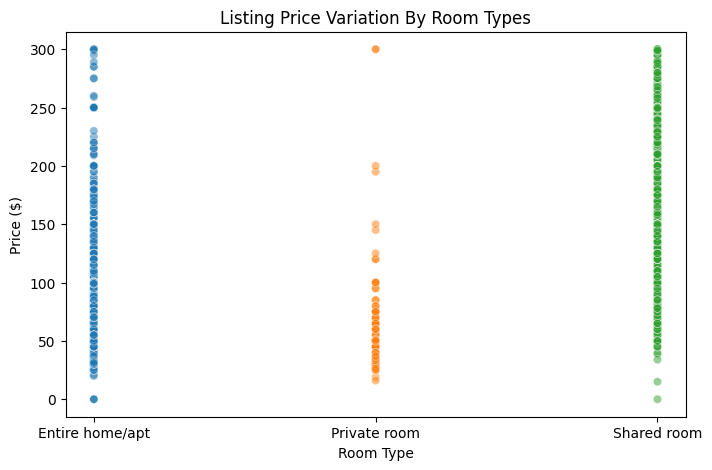

In [41]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='room_type', y='price', hue='room_type', alpha=0.5, data=df, legend=False)
plt.title('Listing Price Variation By Room Types')
plt.xlabel('Room Type')
plt.ylabel('Price ($)')
plt.xticks(ticks=[0, 1, 2], labels=['Entire home/apt', 'Private room', 'Shared room'])

plt.show()

**Interpretation:**

- Entire home/apartment listings have a wide range of prices, including many high-priced (luxury) listings.

- Private rooms are mostly concentrated in the lower to mid-price range.
- Shared rooms generally have the lowest prices.
- This confirms that the room type has a strong influence on each listing price.

### Visualization 3: Correlation Heatmap of Numeric Variables

The heatmap created below displays the correlation between all numeric columns and helps identify which variable is most related to price.

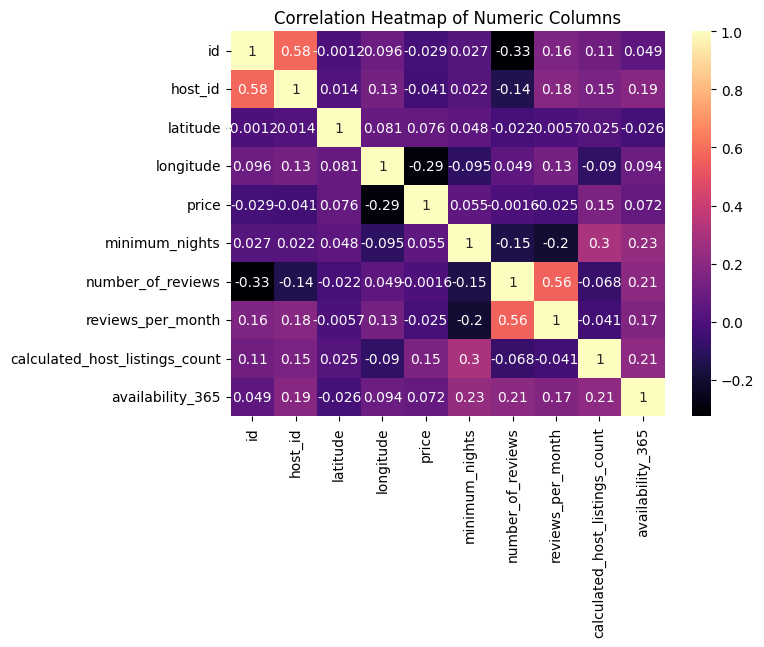

In [43]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='magma')
plt.title('Correlation Heatmap of Numeric Columns')

plt.show()

**Interpretation:**

- Most numeric variables have a weak correlation with price.
- The strongest positive relationship/correlation with price is observed with `calculated_host_listings_count` (around 0.15).
- `longitude` shows a moderate negative correlation.

- Overall, no numeric variable has a strong linear relationship with price, which indicates that categorical factors such as room type and location play a significant role in determining each listing price.

### Visualization 4: Price Variation by Room Type Across Different Neighbourhood Groups

The boxplot produced below shows how price varies by room type across distinct neighbourhood groups (performing a three-variable analysis).

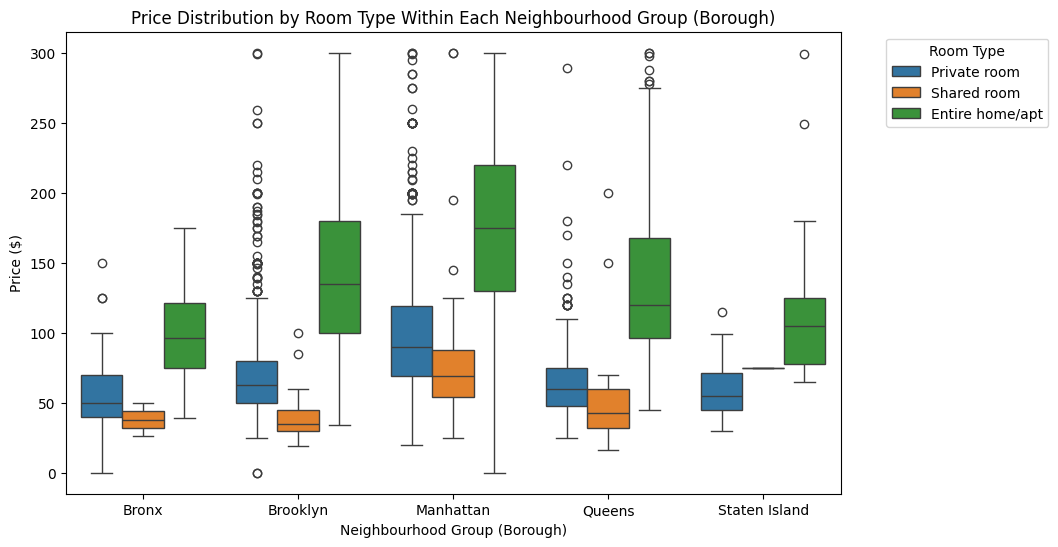

In [44]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='neighbourhood_group', y='price', hue='room_type', data=df)
plt.title('Price Distribution by Room Type Within Each Neighbourhood Group (Borough)')
plt.xlabel('Neighbourhood Group (Borough)')
plt.ylabel('Price ($)')
plt.legend(title='Room Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

**Interpretation:**

- In every neighbourhood group, entire home/apartment listings have the highest median prices.
- Private rooms have moderately higher median prices.
- Shared rooms are the cheapest.
- The price gap is most concentrated in Manhattan.

- This shows that both location and room type together heavily impact each listing price.

## Key Insights and Recommendation
Based on the exploratory data analysis of the New York City Airbnb listings, the following key insights were observed and noted:

1. Manhattan has the highest listing prices among all neighbouring groups, followed by Brooklyn. On the contrary, Bronx and Staten Island have the lowest median prices.
2. Room type strongly influences listing price, such that entire home/apartment listings are significantly more expensive than private rooms, whereas shared rooms are viewed the cheapest.
3. Most listings require only 1 to 5 minimum nights. Very few listings have high minimum stay requirements, which indicates that short-term stays are preferred by majority hosts.
4. Both Brooklyn and Manhattan dominate the market in terms of the number of listings, while Bronx and Staten Island have very limited inventory.
5. Numeric variables have a weak correlation with price. Factors including number of reviews, availability, and host listing count do not heavily affect listing price compared to location and room type.

6. **Actionable Recommendation**:
New hosts should consider listing a private room in Brooklyn or Queens with a minimum stay of 2–3 nights because these regions provide a perfect balance between competitive pricing and demand, allowing new hosts to attract visitor bookings and generate reviews more effectively before shifting towards higher-priced segments such as entire homes/apartments in Manhattan.

In [45]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/numair-2003/AIML-Internship-NumairFahad.git

Mounted at /content/drive
Cloning into 'AIML-Internship-NumairFahad'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 33 (delta 11), reused 12 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (33/33), 290.09 KiB | 7.08 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [ ]:
!cp "/content/drive/MyDrive/Colab Notebooks/Assignment1_EDA_NumairFahad.ipynb" "/content/your-repo/"